
# Online Retail II - Exploratory Data Analysis
Week 1 Internship Task. Objective: explore customer purchase behavior, top products, and country revenue. Observation only, no data removed.


## 1. Imports
pandas for data handling, matplotlib and seaborn for plotting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

## 2. Load Dataset
Both sheets (2009-2010, 2010-2011) read and combined into one DataFrame.

In [2]:
sheet1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
sheet2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
df = pd.concat([sheet1, sheet2], ignore_index=True)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Basic Information
Shape, columns, and data types of the dataset. Requirement 1.

In [3]:
print('Shape:', df.shape)
print(df.dtypes)

Shape: (1067371, 8)
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object


## 4. Missing Values and Duplicates
Count and percentage of missing cells per column, plus duplicate row count. Reported only, nothing removed. Requirement 2.

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Count': missing, 'Percent': missing_pct}))
print('Duplicates:', df.duplicated().sum())

              Count  Percent
Invoice           0     0.00
StockCode         0     0.00
Description    4382     0.41
Quantity          0     0.00
InvoiceDate       0     0.00
Price             0     0.00
Customer ID  243007    22.77
Country           0     0.00
Duplicates: 34335


## 5. Revenue Column
Revenue = Quantity x Price, computed per row. Needed for revenue analysis.

In [5]:
df['Revenue'] = df['Quantity'] * df['Price']
df[['Quantity', 'Price', 'Revenue']].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


## 6. Top 10 Products
Total quantity and total revenue per product, top 10 shown. Requirement 3.

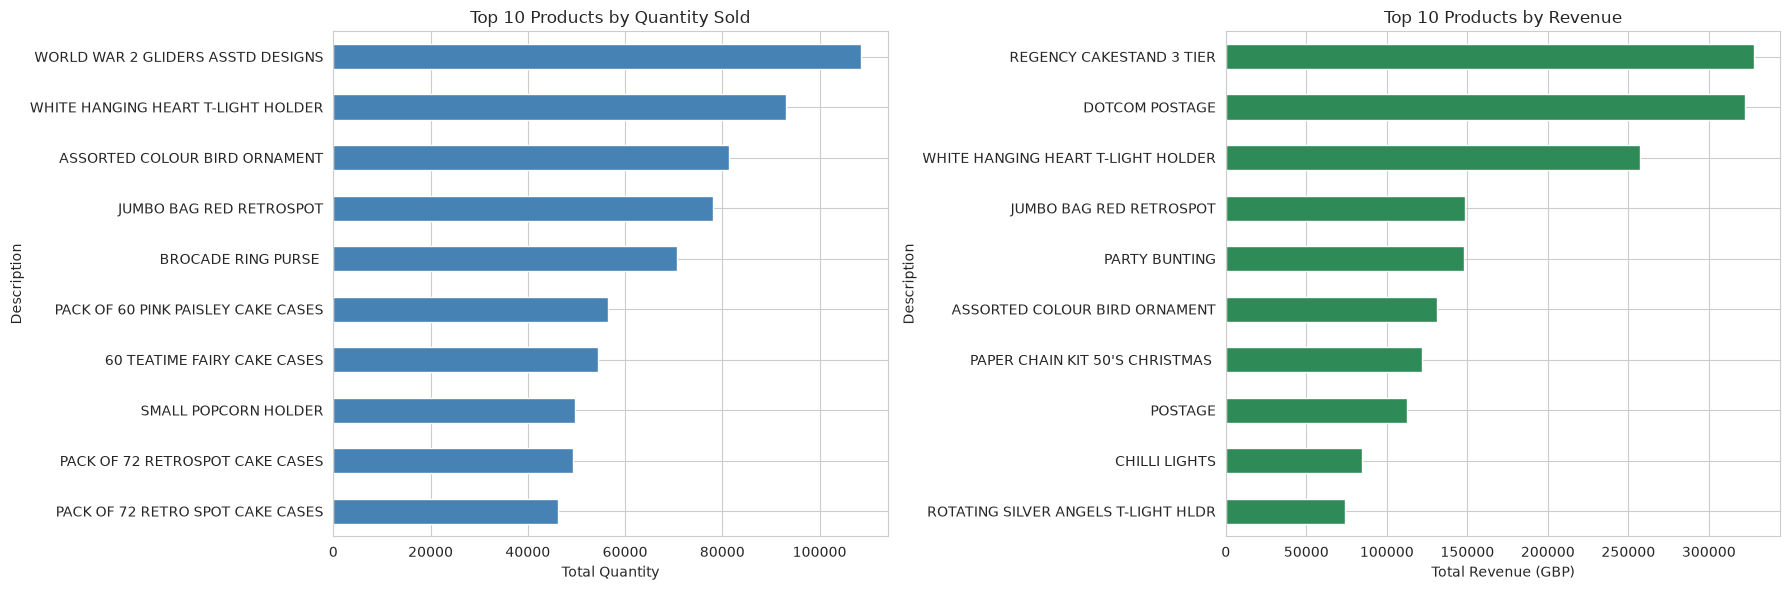

In [6]:
top_qty = df.groupby('Description')['Quantity'].sum().nlargest(10)
top_rev = df.groupby('Description')['Revenue'].sum().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
top_qty.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Products by Quantity Sold')
axes[0].set_xlabel('Total Quantity')
axes[0].invert_yaxis()

top_rev.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Top 10 Products by Revenue')
axes[1].set_xlabel('Total Revenue (GBP)')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Sales by Country
Revenue per country. Second chart excludes UK for readable comparison. Requirement 4.

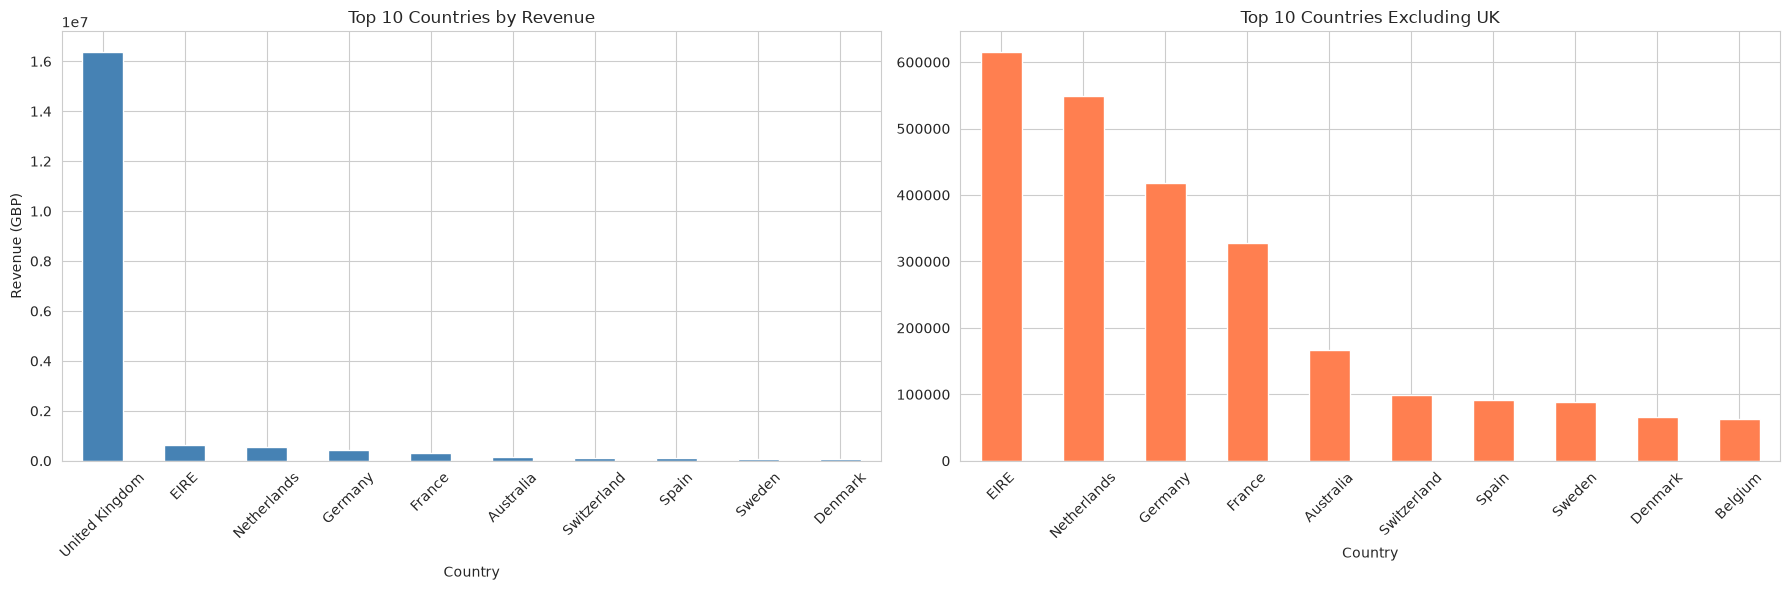

In [7]:
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
country_rev.head(10).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Countries by Revenue')
axes[0].set_ylabel('Revenue (GBP)')
axes[0].tick_params(axis='x', rotation=45)

country_rev.iloc[1:11].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Countries Excluding UK')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 8. Monthly Revenue Trend
Revenue grouped by invoice month, plotted over time. Requirement 5.

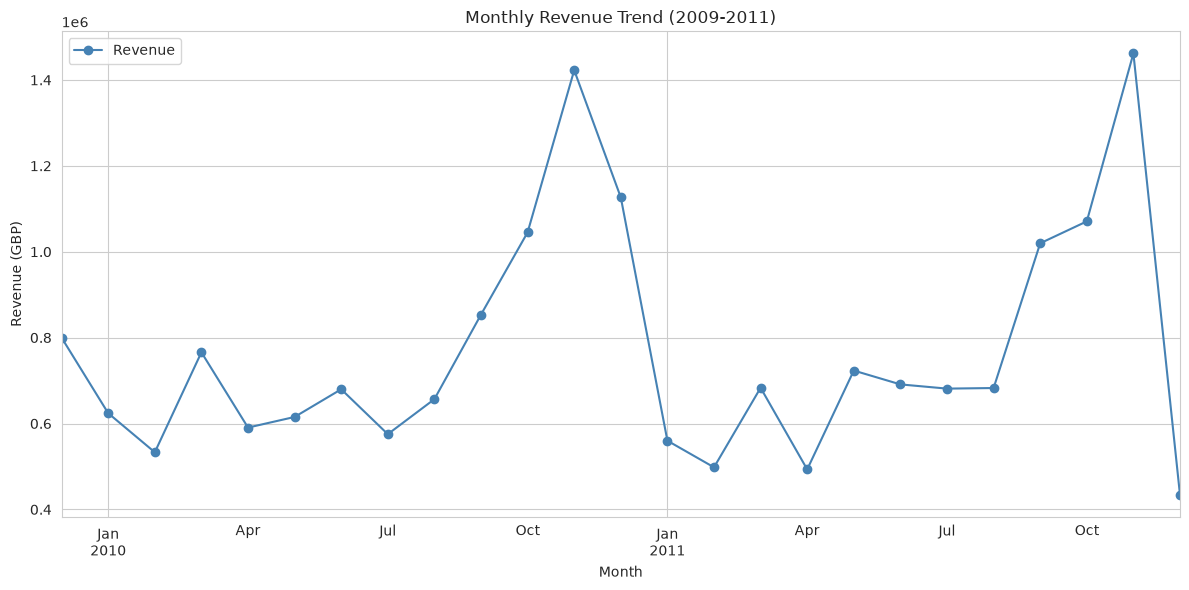

In [8]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('InvoiceMonth')['Revenue'].sum()

ax = monthly.plot(kind='line', marker='o', color='steelblue')
ax.set_title('Monthly Revenue Trend (2009-2011)')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (GBP)')
ax.legend(['Revenue'])
plt.tight_layout()
plt.show()

## 9. Correlation Heatmap
Pearson correlation of numeric columns. Requirement 6.

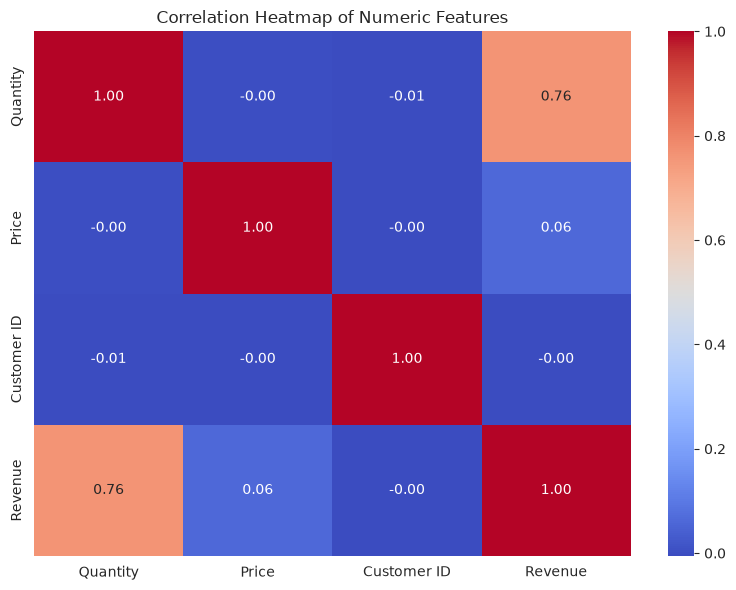

In [9]:
numeric = df.select_dtypes(include='number')
corr = numeric.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## 10. Outlier Detection
Box plots of Quantity and Price. Points beyond 1.5 x IQR are outliers. Requirement 7.

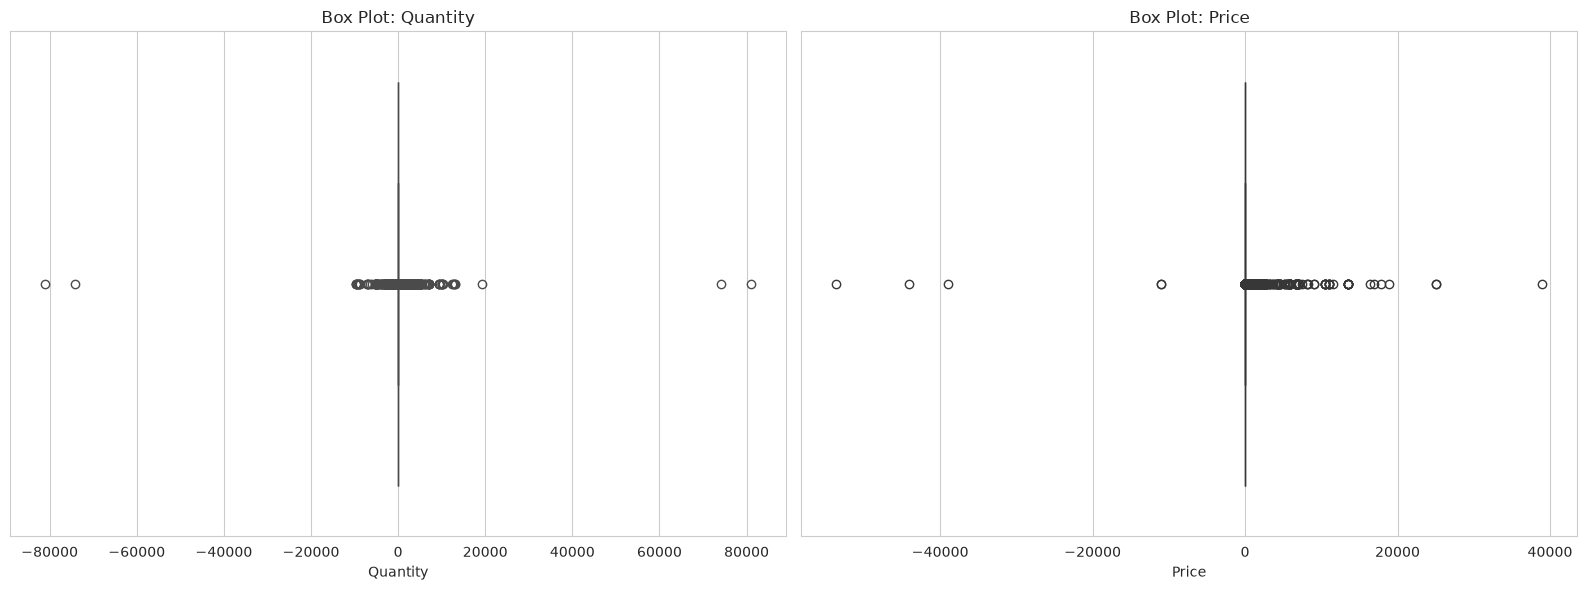

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(x=df['Quantity'], ax=axes[0], color='steelblue')
axes[0].set_title('Box Plot: Quantity')

sns.boxplot(x=df['Price'], ax=axes[1], color='seagreen')
axes[1].set_title('Box Plot: Price')
plt.tight_layout()
plt.show()

## Business Insights

1. **Missing Customer IDs**: 243,007 rows (22.77%) lack a Customer ID, limiting customer level analysis and personalization work.
2. **Duplicates present**: 34,335 duplicate rows found. Reported only, not removed per task rules.
3. **UK dominance**: The United Kingdom generates the large majority of total revenue. International markets are far smaller.
4. **Seasonality**: Monthly revenue peaks in September to November, consistent with holiday season buying, then drops after December.
5. **Quantity drives revenue**: Correlation of Quantity with Revenue is 0.76, while Price with Revenue is 0.06. Volume, not unit price, drives revenue.
6. **Outliers on both sides**: Quantity shows large positive outliers (wholesale orders) and negative values (cancellations, invoices starting with C). Nothing removed at this stage.